# Project Synthesis and Reflection

## Abstract

This project investigates whether sensor-based degradation signals can be identified across two fluid-power systems with different monitoring structures: MetroPT-3, a real operational metro train air compressor dataset, and the Condition Monitoring of Hydraulic Systems dataset, a controlled cycle-based hydraulic test rig. The analysis proceeds through four stages - data loading and cleaning, exploratory data analysis, formal nonparametric hypothesis testing with reliability context, and final synthesis - applied to both datasets in parallel.

The strongest finding is the near-perfect separation of cooler degradation states in the hydraulic dataset, with rank-biserial effect sizes above $0.95$ for temperature-related features. Cross-dataset concordance is strongest for temperature, partial for pressure, and divergent for electrical and load-related behavior. The main limitation is the small number of matched failure events available in MetroPT-3 after coverage filtering, which restricts formal inference to directional and exploratory-supportive evidence.

The results confirm that fluid-power degradation signals are detectable through sensor-based analysis, but their strength and consistency depend strongly on data structure and monitoring context. Temperature emerges as the most transferable concept across both systems, pointing toward thermal-feature-based approaches as a natural starting point for the machine learning stage that follows.

## Introduction

This notebook closes the project by bringing together the main findings from the previous analyses. The project examined predictive maintenance in two fluid-power systems with different monitoring structures: MetroPT-3, a real operational pneumatic compressor dataset, and the Condition Monitoring of Hydraulic Systems dataset, which represents a controlled cycle-based hydraulic test rig.

Because the two datasets differ strongly in labeling, sampling, and operational context, they provide complementary perspectives on the same broader question: whether sensor-based degradation signals can be identified in fluid-power machinery and interpreted in a way that remains meaningful across different systems.

### Project structure

The project is structured across four notebooks. Notebook 01 covers data loading and cleaning for both datasets. Notebook 02 applies exploratory data analysis to identify the strongest feature-condition relationships. Notebook 03 presents formal non-parametric hypothesis testing and reliability analysis. This notebook synthesizes the findings across all stages and reflects on the methodology and limitations of the approach.

## Project synthesis

### Datasets and methods

Two datasets are used throughout the project. MetroPT-3 is a real operational dataset containing approximately seven months of continuous multivariate sensor data from a metro train air compressor, with four documented failure intervals available as event anchors. The hydraulic dataset is a controlled cycle-based experiment covering 2,205 operating cycles, with explicit condition labels for five hydraulic components.

The analytical approach combines exploratory data analysis, formal nonparametric hypothesis testing, and reliability context. Sensor distributions are compared using the Mann-Whitney U test for two-group contrasts and the Kruskal-Wallis omnibus test for multi-level comparisons, with effect sizes reported as rank-biserial correlations and family-wise error controlled through the Bonferroni correction.

### Main findings

### Hypothesis 1

Hypothesis 1 is supported, but with substantially different strength across the two datasets. In the hydraulic dataset, all three formally tested condition labels produce significant results. `cooler_condition` provides the strongest evidence in the entire project, with near-perfect separation across all three degradation levels and rank-biserial effect sizes above 0.95 in five of six pairwise comparisons. `pump_leakage` produces a robust but weaker result ($r = 0.62$), and `stable_flag` produces statistically significant but operationally weak separation ($r = 0.19$ and $0.10$).

In MetroPT-3, formal tests do not reach significance because of the small number of matched failure events available after the coverage filter ($n = 3$ vs $n = 3$ at the event level). The directional evidence remains meaningful: `Oil_temperature` shows a consistent pre-failure shift across all three retained events, while `H1` shows a partial but mostly consistent downward shift across two of the three retained events.

#### Hypothesis 2

Hypothesis 2 is partially supported. Temperature is the strongest shared concept across both systems. In MetroPT-3, `Oil_temperature` shows a consistent pre-failure directional shift at the 6-hour window. In the hydraulic dataset, `TS1_mean` and `TS1_std` produce the strongest formal findings in the entire project. The convergence of thermal evidence across two structurally different systems supports the interpretation that temperature is a meaningful cross-dataset indicator of condition change in fluid-power systems.

Pressure shows partial concordance. `TP2` in MetroPT-3 shows a weak partial pre-failure signal, while pressure-related features play a secondary role in the hydraulic dataset. Electrical and load-related behavior is the most divergent concept: `Motor_current` shows no consistent pre-failure pattern in MetroPT-3, while `EPS1_mean` provides a robust signal for `pump_leakage` in the hydraulic dataset. This divergence is attributable to structural differences in how the concept is captured across the two systems rather than to a contradiction in the underlying physics.

#### Hypothesis 3

Hypothesis 3 is supported mainly through the MetroPT-3 reliability context. The MTTR estimate of approximately $21$ hours and $25$ minutes suggests that the documented air-leak failures were not instantaneous anomalies but corresponded to extended operational interruptions. The MTBF estimate of approximately $28$ days and $9$ hours indicates that failures were infrequent but recurring across the seven-month monitoring period, which is consistent with the sensor-based evidence of detectable pre-failure behavior.

The hydraulic dataset contributes indirect context only. The condition-state proportions confirm substantial representation of both healthy and degraded operating states, supporting the validity of the condition-based comparisons, but no directly comparable time-based reliability metrics are available for the hydraulic system.

The figure below summarizes the magnitude of the hydraulic effect sizes reported in Notebook 03. It highlights the strong separation for cooler-condition comparisons, the moderate pump-leakage effect, and the much weaker stable-flag effects.

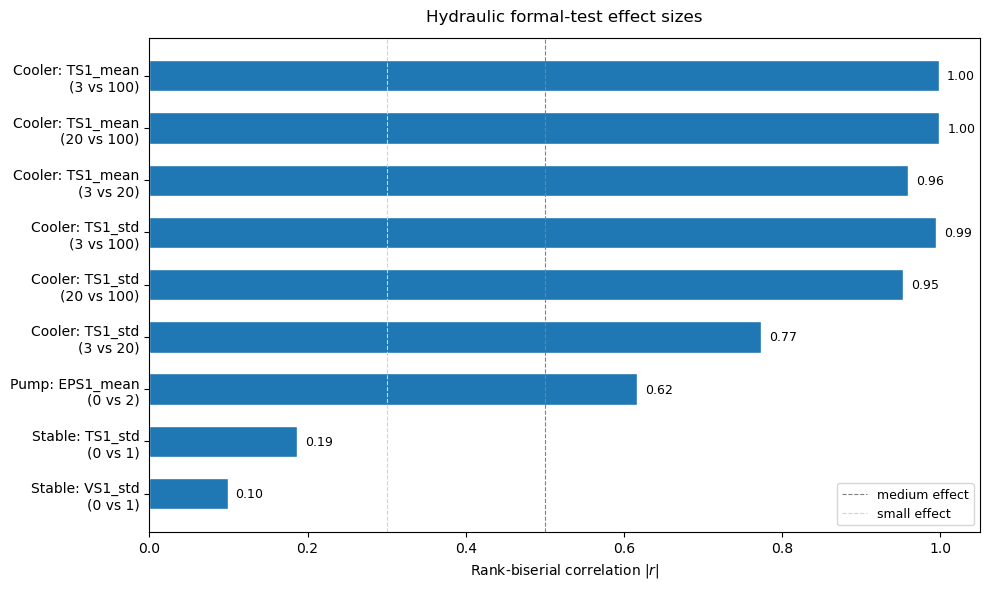

In [3]:
import matplotlib.pyplot as plt

labels = [
    'Stable: VS1_std\n(0 vs 1)',
    'Stable: TS1_std\n(0 vs 1)',
    'Pump: EPS1_mean\n(0 vs 2)',
    'Cooler: TS1_std\n(3 vs 20)',
    'Cooler: TS1_std\n(20 vs 100)',
    'Cooler: TS1_std\n(3 vs 100)',
    'Cooler: TS1_mean\n(3 vs 20)',
    'Cooler: TS1_mean\n(20 vs 100)',
    'Cooler: TS1_mean\n(3 vs 100)',
]

values = [0.0988, 0.1868, 0.6168, 0.7730, 0.9530, 0.9942, 0.9593, 0.9988, 0.9980]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, values, edgecolor='white', height=0.6)

ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, label='medium effect')
ax.axvline(x=0.3, color='lightgray', linestyle='--', linewidth=0.8, label='small effect')

ax.set_xlabel('Rank-biserial correlation $|r|$')
ax.set_title('Hydraulic formal-test effect sizes', pad=12)
ax.set_xlim(0, 1.05)
ax.legend(loc='lower right', fontsize=9)

for bar, val in zip(ax.patches, values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Limitations and methodological reflection

### Main limitations

The most significant constraint in the MetroPT-3 analysis is the small number of matched failure events available after the coverage filter. With only three retained failure events, the formal tests operate at $n = 3$ vs $n = 3$ at the event level, leaving very low statistical power. This is an inherent limitation of the dataset rather than a methodological choice: the monitoring period contains only four documented failure intervals, and one is excluded by the coverage rule.

The window-construction approach introduces its own tradeoffs. The 6-hour pre-failure window is selected based on directional consistency across the sweep, but the choice remains somewhat arbitrary. A longer monitoring period with more failure events would allow a more principled window selection.

The two datasets are fundamentally asymmetric in structure. MetroPT-3 is a continuous operational record with sparse failure annotations, while the hydraulic dataset is a controlled cycle-based experiment with explicit condition labels. This asymmetry means that cross-dataset comparison is conducted by conceptual analogy rather than by direct equivalence, which limits the strength of any conclusions about generalizability.

### Methodological reflection

The decision to conduct hypothesis testing at the event-summary level rather than at the row level was the most consequential methodological choice in the MetroPT-3 analysis. Treating temporally dependent sensor rows as independent observations would likely have produced highly significant results, but those results would have been statistically invalid. The event-level approach is correct, but it reduces the available sample size to the number of failure events rather than the number of rows, which exposes the fundamental data limitation described above.

The nonparametric testing strategy worked well for both datasets. The absence of normality assumptions is appropriate for sensor data with varying distributional shapes across operating regimes, and the combination of significance testing with effect-size reporting provides a more complete interpretation than p-values alone.

In retrospect, a longer monitoring period or additional failure documentation for MetroPT-3 would have strengthened the formal analysis considerably. The hydraulic dataset, by contrast, is well suited to the condition-based testing approach, and the results there are robust and physically interpretable. The contrast between the two datasets ultimately illustrates a broader point: the detectability of degradation signals depends as much on data structure and monitoring design as on the underlying physics of the system.

## Future directions

### Machine learning approach

The exploratory and statistical analyses conducted in this project provide a foundation for a machine-learning stage. The features identified as the strongest discriminators: `TS1_mean` and `TS1_std` for `cooler_condition`, `EPS1_mean` for `pump_leakage`, and `Oil_temperature` for pre-failure behavior in MetroPT-3, are natural candidates for inclusion in a classification or anomaly-detection model. The hydraulic dataset, with its explicit condition labels and clean feature separation, is particularly well suited to a supervised classification approach. MetroPT-3 would require an anomaly-detection or change-point-detection framing because row-level failure labels are not available.

### What additional data would help

The MetroPT-3 analysis would benefit most from a longer monitoring period with more documented failure events. Three matched failure events is insufficient for robust formal inference, and even a modest increase to eight or ten events would substantially improve statistical power. More detailed failure annotations as specifying the onset of degradation rather than only the failure interval, would also allow more principled pre-failure window construction.

For cross-dataset generalization, additional datasets from other fluid-power systems with different components, operating contexts, and monitoring structures would help distinguish system-specific findings from those that reflect broader physical principles. Datasets combining both continuous operational monitoring and explicit condition labels would be particularly valuable, as they would remove the structural asymmetry that limits direct comparison in the current project.

### What the project does not claim

The findings of this project do not establish causal relationships between sensor behavior and equipment degradation. The statistical associations identified are consistent with physical interpretations, but correlation and physical plausibility are not equivalent to causation.

The project does not produce a deployable predictive maintenance model. The analyses are exploratory and confirmatory in nature, establishing which sensor concepts carry degradation-related information and how strongly, but stopping short of building or validating a prediction system.

The cross-dataset findings do not constitute a universal degradation signature for fluid-power systems. The two datasets represent specific
components under specific operating conditions, and the degree to which the identified patterns generalize to other systems remains an open
question.

## Closing note

This project set out to investigate whether sensor-based degradation signals can be identified across two fluid-power systems with different monitoring structures. The answer is yes, but with important qualifications.

The hydraulic dataset demonstrates that engineered cycle-level features can separate degradation states very cleanly under controlled conditions. The cooler-condition signal in particular is one of the strongest results obtainable from this kind of analysis. The MetroPT-3 dataset demonstrates something equally important: that the same physical concepts - temperature, pressure, electrical load - remain directionally informative even under real field operation, where operating-regime variability, sparse failure annotations, and temporal dependence all work against clean separation.

The two-dataset design was the central methodological choice of this project, and it proved its value. Neither dataset alone would have told the full story. Together, they illustrate both what sensor-based predictive maintenance can achieve under favorable conditions and what it must contend with in the field.

## References

### Datasets

Veloso, B., Ribeiro, R. P., Gama, J., & Pereira, P. M. (2022). The MetroPT dataset for predictive maintenance. *Scientific Data*, 9, 764.
https://doi.org/10.1038/s41597-022-01877-3

Helwig, N., Pignanelli, E., & Schütze, A. (2015). Condition monitoring of a complex hydraulic system using multivariate statistics. *Proceedings of the 2015 IEEE International Instrumentation and Measurement Technology Conference (I2MTC)*, 210-215. https://doi.org/10.1109/I2MTC.2015.7151267

### Statistical methods

Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *The Annals of Mathematical Statistics*, 18(1), 50-60.

Kerby, D. S. (2014). The simple difference formula: An approach to teaching nonparametric correlation. *Comprehensive Psychology*, 3, 11-IT.

Dunn, O. J. (1961). Multiple comparisons among means. *Journal of the American Statistical Association*, 56(293), 52-64.

Kruskal, W. H., & Wallis, W. A. (1952). Use of ranks in one-criterion variance analysis. Journal of the American Statistical Association, 47(260), 583-621.

### Software

Virtanen, P., Gommers, R., Oliphant, T. E., et al. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261-272. https://doi.org/10.1038/s41592-019-0686-2

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92-96.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90-95.

Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. Nature, 585, 357-362.

### Reliability engineering

IEC 60050-192:2015. International Electrotechnical Vocabulary - Part 192: Dependability. International Electrotechnical Commission.

### Acknowledgments

This project was developed with the assistance of Claude (Anthropic).

The use of MTBF and MTTR as supporting reliability metrics was suggestedby Kamend1 (Discord).

---
$$ \text{Cross-Dataset Predictive Maintenance of Fluid-Power Systems}$$
$$\blacksquare $$